In [122]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [123]:
data = pd.read_csv(r"/workspaces/ml/random-forest/Heart_Disease_Prediction.csv")
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


In [124]:
x = data.drop("Heart Disease", axis = 1)
y = data["Heart Disease"]

In [125]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x , y ,
    test_size= 0.2,
    random_state=42,
    stratify = y
)

In [126]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

In [127]:
rf_model.fit(X_train,Y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [128]:
y_pred = rf_model.predict(X_test)

In [129]:
print("Accuracy :", accuracy_score(Y_test, y_pred))

Accuracy : 0.8518518518518519


In [130]:
print("Classification Report:")
print(classification_report(Y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

     Absence       0.87      0.87      0.87        30
    Presence       0.83      0.83      0.83        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54



In [131]:
print(Y_test.values)
print("\n", y_pred)

<StringArray>
[ 'Absence',  'Absence',  'Absence', 'Presence',  'Absence',  'Absence',
  'Absence', 'Presence', 'Presence', 'Presence',  'Absence', 'Presence',
  'Absence',  'Absence', 'Presence', 'Presence',  'Absence', 'Presence',
  'Absence', 'Presence',  'Absence', 'Presence',  'Absence',  'Absence',
  'Absence', 'Presence',  'Absence',  'Absence',  'Absence',  'Absence',
  'Absence', 'Presence', 'Presence',  'Absence',  'Absence',  'Absence',
 'Presence',  'Absence', 'Presence',  'Absence', 'Presence', 'Presence',
 'Presence', 'Presence',  'Absence',  'Absence',  'Absence', 'Presence',
  'Absence', 'Presence', 'Presence', 'Presence',  'Absence', 'Presence']
Length: 54, dtype: str

 ['Absence' 'Absence' 'Absence' 'Presence' 'Absence' 'Absence' 'Absence'
 'Presence' 'Presence' 'Presence' 'Absence' 'Absence' 'Absence' 'Presence'
 'Presence' 'Presence' 'Absence' 'Presence' 'Absence' 'Presence' 'Absence'
 'Presence' 'Absence' 'Absence' 'Absence' 'Presence' 'Absence' 'Absence'
 'Absence

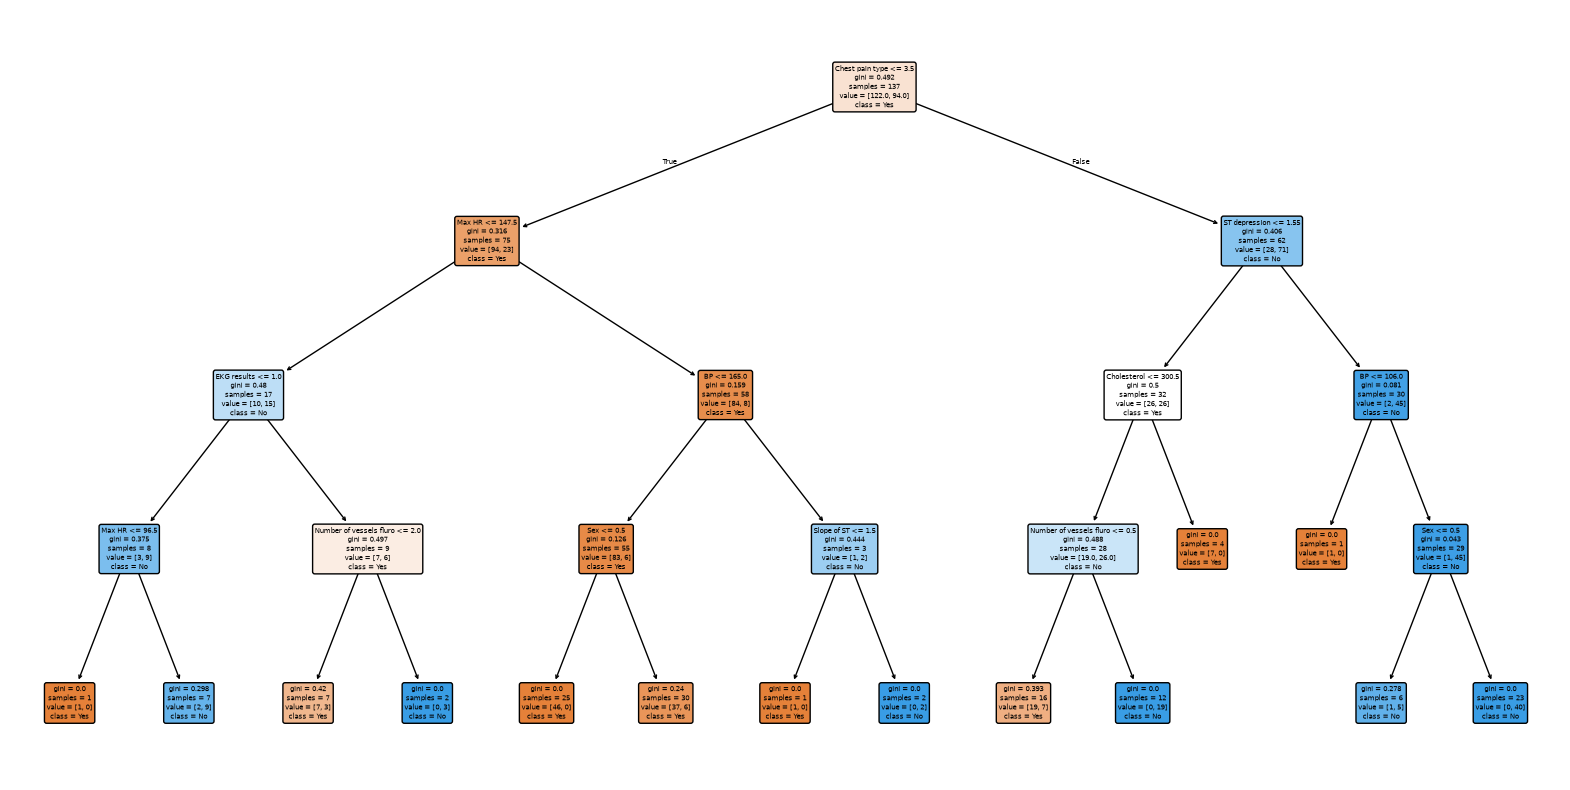

In [132]:
plt.figure (figsize=(20,10))

plot_tree(
    rf_model.estimators_[99],
    feature_names = x.columns,
    class_names = ['Yes' , 'No'],
    filled = True,
    rounded = True

)

plt.show()